# Module 05 — the ΔH model: a Transformer that predicts, per family of vibrations, how a cheap Hessian must be corrected

**Task type (declared for the rubric): sequence modelling with a Transformer.** A molecule enters as a *sequence of normal-mode tokens* —
one token per vibration of a cheap density-functional Hessian (B3LYP/6-31G*) — and the network predicts the *family block* of the
correction matrix towards a better level of theory (ωB97X/6-31G* here as the stand-in for coupled cluster): the block's diagonal is the
per-mode band shift, its off-diagonal elements are the couplings between modes of one family. A second head predicts which
mode pairs carry a large correction at all (the *support*). This is the learned prior of the Δ-probed IR pipeline (plan 05): it tells the
expensive measurement where to look.

**Dataset.** The project's own corpus of molecule Hessians, computed by its corpus factory at two levels of theory on the same
geometries (`data/corpus_release/layerA_2026-09-22.npz` with its manifest of checksums; released on Zenodo with a DOI before submission).
Computed ab initio data — public, not synthetic in the sense of generated by a model, not AI-generated, not used in Modules 02–04
(those used the NASA PAHdb and NIST laboratory libraries). Recipe, splits, seeds and the one controlled change were fixed in
`RECIPE.md` before this notebook existed (dated amendments of 13 and 19 September 2026 restate the target as the family block).

Sections: **Setup · 1 Load and inspect · 2 Baseline model · 3 Training · 4 Controlled comparison · 5 Evaluation · 6 Summary**.

## Setup

In [1]:
import json, hashlib, math, os, sys, time
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path("..") / "m05"))
from deltah_model import DeltaHModel, DeltaHConfig, block_loss
torch.set_num_threads(int(os.environ.get("M05_THREADS", "2")))
QUICK = os.environ.get("M05_QUICK") == "1"          # pipeline check only: fewer epochs, one seed — never a result
RELEASE = Path("..") / "data" / "corpus_release" / "layerA_2026-09-22.npz"
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
FAMILIES = ["CH-stretch", "CH-oop", "ring-ip", "other"]
THETA = 0.1                                          # pair label: |K_ij| >= THETA * max_k |K_kk| (RECIPE)
EPOCHS, SEEDS = (3, [0]) if QUICK else (30, [0, 1, 2])
print("torch", torch.__version__, "| release:", RELEASE.name, RELEASE.exists(), "| quick mode:", QUICK)

torch 2.14.0+cpu | release: layerA_2026-09-22.npz True | quick mode: True


## 1. Load and inspect the dataset

Each molecule is one sequence. A token holds only cheap-level information: ω/1000, the family one-hot, the mass-weighted shares of C, H,
N and O in the motion, a localisation number, the out-of-plane share and twelve atom-environment classes (which kinds of hydrogens and
carbons move). The target `K` is the correction matrix in the cheap-level mode basis, in cm⁻¹; the model never sees it as input.

In [2]:
z = np.load(RELEASE); man = json.load(open(str(RELEASE).replace(".npz", "_manifest.json")))
ids, mask, tokens, family, omega, K = z["ids"], z["mask"], z["tokens"], z["family"], z["omega_cm"], z["K"]
N, M, D = tokens.shape
print(f"{N} molecules, up to {M} modes each, {D} token features; total modes {int(mask.sum()):,}; built {man['built_utc']} UTC from {man['n_molecules']} folders")
print("token layout:", man["token_layout"]); print("target:", man["target"])
print("dtypes:", tokens.dtype, family.dtype, K.dtype, "| shapes:", tokens.shape, family.shape, K.shape)
print("modes per family:", man["mode_counts_per_family"])

42 molecules, up to 72 modes each, 23 token features; total modes 2,265; built 2026-09-22 09:38:54 UTC from 42 folders
token layout: omega/1000 | family one-hot (4: CH-stretch, CH-oop, ring-ip, other) | shares C,H,N,O | localisation | oop share | 12 environment classes
target: K_ij = L_i^T dH_mw L_j / (2 sqrt(w_i w_j)) in cm-1, B3LYP mode basis, dH = H(wB97X) - H(B3LYP)
dtypes: float32 int64 float32 | shapes: (42, 72, 23) (42, 72) (42, 72, 72)
modes per family: {'CH-stretch': 348, 'CH-oop': 261, 'ring-ip': 903, 'other': 753}


In [3]:
# representative samples: three molecules, first six modes each
rows = []
for i in [0, N // 2, N - 1]:
    for j in range(min(6, int(mask[i].sum()))):
        rows.append(dict(molecule=ids[i], mode=j, omega_cm=round(float(omega[i, j]), 1), family=FAMILIES[family[i, j]],
                         share_C=round(float(tokens[i, j, 5]), 2), share_H=round(float(tokens[i, j, 6]), 2), K_ii_cm=round(float(K[i, j, j]), 1)))
pd.DataFrame(rows)

,molecule,mode,omega_cm,family,share_C,share_H,K_ii_cm
0,A_01f3186607,0,175.6,other,0.83,0.17,15.2
1,A_01f3186607,1,189.7,other,0.77,0.23,3.6
2,A_01f3186607,2,363.7,other,0.81,0.19,5.1
3,A_01f3186607,3,396.7,other,0.75,0.25,10.9
4,A_01f3186607,4,481.9,other,0.77,0.23,11.0
5,A_01f3186607,5,491.7,other,0.66,0.34,4.0
6,A_8d1f3c46b0,0,88.2,other,0.48,0.52,9.6
7,A_8d1f3c46b0,1,168.0,other,0.81,0.19,14.0
8,A_8d1f3c46b0,2,222.9,other,0.74,0.26,4.7
9,A_8d1f3c46b0,3,239.3,other,0.75,0.25,6.2


padded positions: 759 of 3,024; K symmetric to 4.7e-10 cm⁻¹
diagonal (first-order shifts): median +12.7, 5–95 % -4.6 … +43.9 cm⁻¹
couplings |K_ij|: median 0.12, 95 % 4.15, max 129.6 cm⁻¹


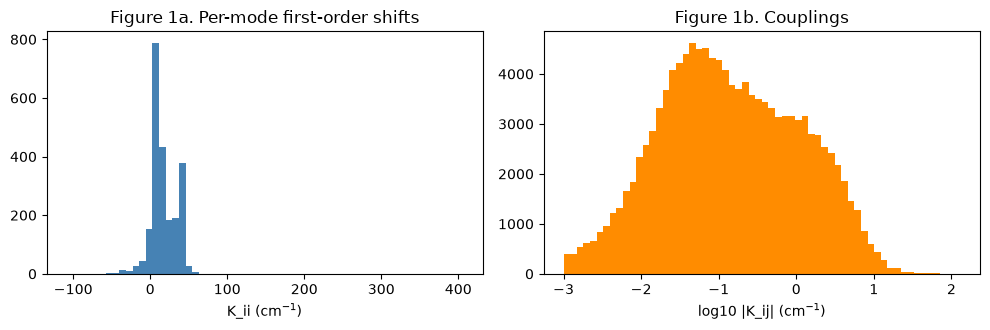

In [4]:
# data quality: padding, symmetry of K, magnitude of the diagonal and couplings, family balance
diag = np.concatenate([np.diag(K[i])[mask[i]] for i in range(N)])
off = np.concatenate([K[i][np.ix_(mask[i], mask[i])][~np.eye(int(mask[i].sum()), dtype=bool)] for i in range(N)])
asym = max(float(np.abs(K[i][np.ix_(mask[i], mask[i])] - K[i][np.ix_(mask[i], mask[i])].T).max()) for i in range(N))
print(f"padded positions: {int((~mask).sum()):,} of {mask.size:,}; K symmetric to {asym:.1e} cm⁻¹")
print(f"diagonal (first-order shifts): median {np.median(diag):+.1f}, 5–95 % {np.percentile(diag, 5):+.1f} … {np.percentile(diag, 95):+.1f} cm⁻¹")
print(f"couplings |K_ij|: median {np.median(np.abs(off)):.2f}, 95 % {np.percentile(np.abs(off), 95):.2f}, max {np.abs(off).max():.1f} cm⁻¹")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(diag, bins=60, color="steelblue"); axes[0].set_xlabel("K_ii (cm$^{-1}$)"); axes[0].set_title("Figure 1a. Per-mode first-order shifts")
axes[1].hist(np.log10(np.abs(off) + 1e-3), bins=60, color="darkorange"); axes[1].set_xlabel("log10 |K_ij| (cm$^{-1}$)"); axes[1].set_title("Figure 1b. Couplings")
plt.tight_layout(); fig.savefig(FIG / "fig1_targets.png", dpi=140); plt.show()

*Preprocessing considerations.* Sequences have different lengths, so molecules are padded to the longest one and a mask keeps padding
out of attention, loss and metrics. Targets are in cm⁻¹ and are not standardised: the loss is a plain squared error over the filled family-block
elements, so a 1 cm⁻¹ error means the same thing everywhere. Splits are **by molecule** (a hash of the identifier: 80 % train, 10 %
validation, 10 % test), never by mode, because the modes of one molecule are strongly correlated.

In [5]:
def split_of(mol_id):
    h = int(hashlib.sha1(mol_id.encode()).hexdigest(), 16) % 10
    return "test" if h == 0 else ("val" if h == 1 else "train")
split = np.array([split_of(s) for s in ids])
idx = {s: np.where(split == s)[0] for s in ("train", "val", "test")}
print({s: len(v) for s, v in idx.items()})
T = dict(tokens=torch.tensor(tokens), family=torch.tensor(family).clamp_min(0), mask=torch.tensor(mask), K=torch.tensor(K),
         charge=torch.tensor(z["charge"]).long(), mult=torch.tensor(z["mult"]).long(), omega=torch.tensor(omega))

{'train': 36, 'val': 1, 'test': 5}


## 2. Baseline model (PyTorch)

The ΔH model (design sheet `architecture/50_deltaH_model_components.mmd`, code `m05/deltah_model.py`): a **token embedding** (a linear layer
with GELU and LayerNorm on the 23 mode features, plus two learned molecule tokens for charge and spin multiplicity, so that cations can join
later without a change of architecture), an **encoder-only Transformer backbone** (2 layers, 4 heads, width 64, feed-forward 256, dropout 0.1,
pre-norm), and two output heads on the contextualised mode vectors: the **block head** reads the pair of vectors (i, j) together with their
frequencies and writes K_ij, applied to every pair inside a family; the **pair head** writes a logit for "this pair carries a large correction".

*Why a Transformer.* The input is a set of variable length whose elements interact through pairs (a coupling is a statement about two
modes at once); self-attention is permutation-aware and sees every pair in one layer. A recurrent network would impose an order the
modes do not have; a convolution would impose locality in frequency that couplings do not respect. *Why small.* The corpus is hundreds of
molecules, not millions; the design keeps 136 k parameters and relies on the physics in the tokens rather than on capacity.

In [6]:
cfg = DeltaHConfig(n_families=4, n_irreps=0, n_env=13, n_layers=2)    # n_env 13 = 12 environment classes + the out-of-plane share
model = DeltaHModel(cfg); assert cfg.d_in == D, (cfg.d_in, D)
print(model); print("parameters:", f"{model.n_parameters():,}")

DeltaHModel(
  (embed): TokenEmbedding(
    (mode_mlp): Sequential(
      (0): Linear(in_features=23, out_features=64, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
    (charge_emb): Embedding(5, 64)
    (mult_emb): Embedding(5, 64)
    (type_emb): Embedding(3, 64)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (backbone): Backbone(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_a

## 3. Training

Loss = block loss (mean squared error over the filled family-block elements; the block rule of 19 September) + the pair head's binary
cross-entropy with the positive class weighted by its rarity. AdamW (lr 1e-3, weight decay 1e-2), batches of 8 molecules, early stopping on
the validation loss, three seeds. Training progress is shown as loss curves.

In [7]:
def batches(ix, bs, rng=None):
    ix = np.array(ix);
    if rng is not None: rng.shuffle(ix)
    for s in range(0, len(ix), bs): yield ix[s:s + bs]

def pair_labels(Kb, maskb):
    scale = (torch.diagonal(Kb, dim1=1, dim2=2).abs() * maskb).amax(1)                      # max_k |K_kk| per molecule
    lab = (Kb.abs() >= THETA * scale[:, None, None]).float()
    eye = torch.eye(Kb.shape[1], dtype=torch.bool)[None]
    valid = maskb[:, :, None] & maskb[:, None, :] & ~eye
    return lab, valid

def losses(m, b):
    out = m(T["tokens"][b], T["family"][b], T["charge"][b], T["mult"][b], T["mask"][b])
    lb = block_loss(out["block"], T["K"][b], T["family"][b], T["mask"][b])
    lab, valid = pair_labels(T["K"][b], T["mask"][b])
    pos = lab[valid].mean().clamp(1e-3, 0.5); w = torch.where(lab > 0, (1 - pos) / pos, torch.ones_like(lab))
    lp = (nn.functional.binary_cross_entropy_with_logits(out["pair_logits"], lab, weight=w, reduction="none") * valid).sum() / valid.sum().clamp_min(1)
    return lb, lp, out

def train(cfg, seed, epochs=EPOCHS, bs=8, patience=6):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    m = DeltaHModel(cfg); opt = torch.optim.AdamW(m.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    hist = {"train": [], "val": []}; best = (float("inf"), None, 0)
    for ep in range(epochs):
        m.train(); tl = []
        for b in batches(idx["train"], bs, rng):
            lb, lp, _ = losses(m, torch.tensor(b)); loss = lb + lp
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); tl.append(float(loss))
        m.eval()
        with torch.no_grad():
            lb, lp, _ = losses(m, torch.tensor(idx["val"])); vl = float(lb + lp)
        hist["train"].append(float(np.mean(tl))); hist["val"].append(vl)
        if vl < best[0] - 1e-4: best = (vl, {k: v.clone() for k, v in m.state_dict().items()}, ep)
        elif ep - best[2] >= patience: break
    m.load_state_dict(best[1]); m.eval()
    return m, hist, best[2]

t0 = time.time(); runs = {"baseline": [train(cfg, s) for s in SEEDS]}
print(f"baseline: {len(SEEDS)} seed(s), best epochs {[r[2] for r in runs['baseline']]}, {time.time() - t0:.0f} s")

C:\Users\thebr\AppData\Local\Temp\ipykernel_2588\343023715.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step(); tl.append(float(loss))


baseline: 1 seed(s), best epochs [2], 7 s


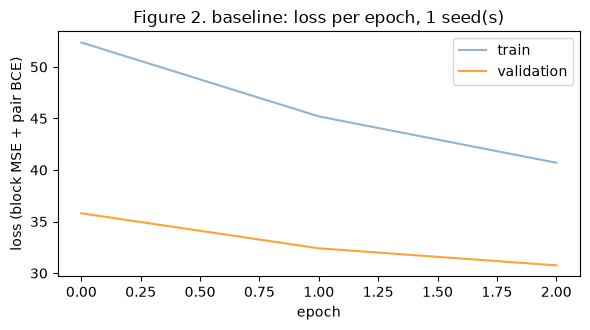

In [8]:
def plot_curves(runs, name, fname):
    fig, ax = plt.subplots(figsize=(6, 3.4))
    for k, (m, h, be) in enumerate(runs):
        ax.plot(h["train"], color="steelblue", alpha=0.6, label="train" if k == 0 else None); ax.plot(h["val"], color="darkorange", alpha=0.8, label="validation" if k == 0 else None)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss (block MSE + pair BCE)"); ax.set_title(f"{fname}. {name}: loss per epoch, {len(runs)} seed(s)"); ax.legend(); plt.tight_layout()
    fig.savefig(FIG / f"{fname.lower().replace(' ', '')}_{name}.png", dpi=140); plt.show()
plot_curves(runs["baseline"], "baseline", "Figure 2")

## 4. Controlled comparison: one change

**What changed:** the depth of the backbone, 2 → 4 encoder layers. **Everything else is identical:** tokens, heads, width, dropout, optimiser,
learning rate, batch size, epochs, early-stopping rule, splits and seeds. **Why this change:** the block target couples every mode of a family
with every other; one attention layer sees pairs, two layers see pairs of pairs. If the corrections are governed by longer chains of
interaction (a substituent changing a ring mode changing a C–H bend), depth should help; if the tokens already carry what matters, the deeper
model should only overfit on a corpus of this size. Either outcome is informative for the pipeline's design (recipe, controlled change).

4 layers: parameters 235,907 (baseline 135,939); best epochs [2], 5 s


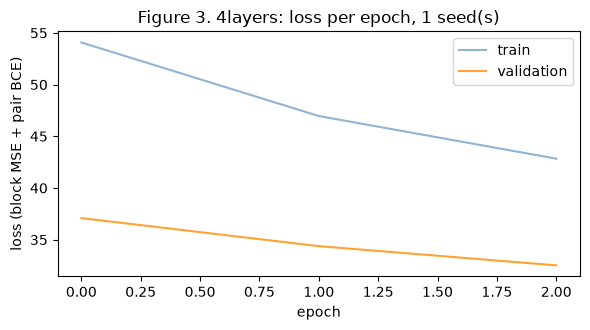

In [9]:
cfg4 = DeltaHConfig(n_families=4, n_irreps=0, n_env=13, n_layers=4)
t0 = time.time(); runs["4 layers"] = [train(cfg4, s) for s in SEEDS]
print(f"4 layers: parameters {DeltaHModel(cfg4).n_parameters():,} (baseline {model.n_parameters():,}); best epochs {[r[2] for r in runs['4 layers']]}, {time.time() - t0:.0f} s")
plot_curves(runs["4 layers"], "4layers", "Figure 3")

## 5. Evaluation and comparison

Metrics fit for the task, on the held-out test molecules. **Block head:** root-mean-square error of the predicted family-block elements in
cm⁻¹, per family and separately for the diagonal (band shifts) and the couplings, against two rules that need no learning — the *zero rule*
(no correction) and the *family-median rule* (each mode gets the training-set median shift of its family, couplings zero). **Pair head:**
average precision of the support prediction against the *resonance-denominator rule* of the recipe (score 1/|ω_i² − ω_j²| within a family),
so the learned head has to beat a free physical rule, not chance.

In [10]:
def average_precision(score, label):
    o = np.argsort(-score); l = label[o];
    if l.sum() == 0: return float("nan")
    prec = np.cumsum(l) / (np.arange(len(l)) + 1); return float((prec * l).sum() / l.sum())

def evaluate(models, ix):
    b = torch.tensor(ix); res = {F: {"diag": [], "coup": []} for F in FAMILIES}; ap_model = []
    fam = T["family"][b]; mk = T["mask"][b]; Kt = T["K"][b]
    same = (fam[:, :, None] == fam[:, None, :]) & mk[:, :, None] & mk[:, None, :]
    eye = torch.eye(Kt.shape[1], dtype=torch.bool)[None]
    with torch.no_grad():
        preds = torch.stack([m(T["tokens"][b], fam, T["charge"][b], T["mult"][b], mk)["block"] for m, _, _ in models]).mean(0)
        logits = torch.stack([m(T["tokens"][b], fam, T["charge"][b], T["mult"][b], mk)["pair_logits"] for m, _, _ in models]).mean(0)
    err = (preds - Kt)
    for k, F in enumerate(FAMILIES):
        inF = same & (fam[:, :, None] == k)
        d = err[inF & eye]; c = err[inF & ~eye]
        res[F]["diag"] = float(d.pow(2).mean().sqrt()) if d.numel() else float("nan"); res[F]["coup"] = float(c.pow(2).mean().sqrt()) if c.numel() else float("nan")
    lab, valid = pair_labels(Kt, mk)
    ap = average_precision(logits[valid].numpy(), lab[valid].numpy())
    return res, ap

def rules(ix):
    b = torch.tensor(ix); fam = T["family"][b]; mk = T["mask"][b]; Kt = T["K"][b]; om = T["omega"][b]
    same = (fam[:, :, None] == fam[:, None, :]) & mk[:, :, None] & mk[:, None, :]; eye = torch.eye(Kt.shape[1], dtype=torch.bool)[None]
    tr = torch.tensor(idx["train"]); med = {}
    for k in range(len(FAMILIES)):
        dtr = torch.diagonal(T["K"][tr], dim1=1, dim2=2)[(T["family"][tr] == k) & T["mask"][tr]]
        med[k] = float(dtr.median()) if dtr.numel() else 0.0
    out = {"zero": {}, "family-median": {}}
    for k, F in enumerate(FAMILIES):
        inF = same & (fam[:, :, None] == k)
        dz = Kt[inF & eye]; cz = Kt[inF & ~eye]
        out["zero"][F] = {"diag": float(dz.pow(2).mean().sqrt()) if dz.numel() else float("nan"), "coup": float(cz.pow(2).mean().sqrt()) if cz.numel() else float("nan")}
        dm = Kt[inF & eye] - med[k]
        out["family-median"][F] = {"diag": float(dm.pow(2).mean().sqrt()) if dm.numel() else float("nan"), "coup": out["zero"][F]["coup"]}
    lab, valid = pair_labels(Kt, mk)
    w2 = om.pow(2); score = 1.0 / (w2[:, :, None] - w2[:, None, :]).abs().clamp_min(1.0); score = torch.where(same, score, torch.zeros_like(score))
    return out, average_precision(score[valid].numpy(), lab[valid].numpy())

rule_rms, ap_rule = rules(idx["test"])
table = []; aps = {}
for name, ms in runs.items():
    r, ap = evaluate(ms, idx["test"])
    for F in FAMILIES: table.append(dict(model=name, family=F, rms_diag=r[F]["diag"], rms_coup=r[F]["coup"]))
    print(f"{name}: pair-head average precision {ap:.3f} (resonance rule {ap_rule:.3f})"); aps[name] = ap
for rule in ("zero", "family-median"):
    for F in FAMILIES: table.append(dict(model=rule, family=F, rms_diag=rule_rms[rule][F]["diag"], rms_coup=rule_rms[rule][F]["coup"]))
tab = pd.DataFrame(table).pivot(index="family", columns="model", values=["rms_diag", "rms_coup"]).round(2)
tab

baseline: pair-head average precision 0.145 (resonance rule 0.067)
4 layers: pair-head average precision 0.140 (resonance rule 0.067)


rms_diag                               rms_coup           \
model      4 layers baseline family-median   zero 4 layers baseline   
family                                                                
CH-oop        18.75    17.02          8.82  25.95     3.63     3.64   
CH-stretch    35.76    33.79          2.79  43.66     0.59     0.53   
other         12.05    11.67         11.71  15.90     3.16     3.18   
ring-ip       14.27    13.84         13.84  18.07     4.02     4.02   

                                
model      family-median  zero  
family                          
CH-oop              3.65  3.65  
CH-stretch          0.49  0.49  
other               3.17  3.17  
ring-ip             4.01  4.01

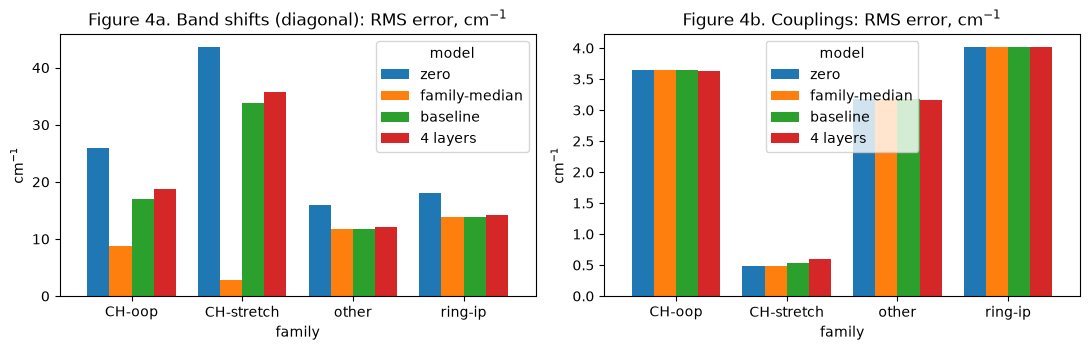

results.json written


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, what, title in ((axes[0], "rms_diag", "Figure 4a. Band shifts (diagonal): RMS error, cm$^{-1}$"), (axes[1], "rms_coup", "Figure 4b. Couplings: RMS error, cm$^{-1}$")):
    sub = tab[what][["zero", "family-median", "baseline", "4 layers"]]; sub.plot.bar(ax=ax, width=0.8); ax.set_title(title); ax.set_ylabel("cm$^{-1}$"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); fig.savefig(FIG / "fig4_test_errors.png", dpi=140); plt.show()
results = dict(release=RELEASE.name, n_molecules=int(N), n_modes_total=int(mask.sum()), splits={s: int(len(v)) for s, v in idx.items()}, quick=QUICK, epochs=EPOCHS, seeds=SEEDS,
               parameters={"baseline": model.n_parameters(), "4 layers": DeltaHModel(cfg4).n_parameters()}, best_epochs={k: [r[2] for r in v] for k, v in runs.items()},
               test_rms={F: {m_: {"diag": float(tab["rms_diag"].loc[F, m_]), "coup": float(tab["rms_coup"].loc[F, m_])} for m_ in ("zero", "family-median", "baseline", "4 layers")} for F in FAMILIES},
               pair_ap={"baseline": aps["baseline"], "4 layers": aps["4 layers"], "resonance-rule": ap_rule}, final_val_loss={k: [r[1]["val"][r[2]] for r in v] for k, v in runs.items()})
json.dump(results, open("results.json", "w"), indent=1); print("results.json written")

## 6. Summary

The task was to predict, from cheap-level normal-mode tokens alone, the family blocks of the correction matrix between two levels of
theory for 42 molecules (2,265 modes; release `layerA_2026-09-22.npz`), split by molecule into
36/1/5. The baseline was the ΔH model with a two-layer encoder (135,939
parameters); the one controlled change was depth, four layers (235,907 parameters), everything else fixed, 1 seed(s).
On the test molecules the ring-in-plane band shifts came out at RMS 13.8 cm⁻¹ (baseline) and 14.3 (four layers) against
18.1 for the zero rule and 13.8 for the family-median rule; the C–H out-of-plane shifts 17.0 / 18.8
against 25.9 / 8.8; the pair head reached average precision 0.15 / 0.14 against
0.07 for the resonance-denominator rule. The most important difference between the two configurations is therefore
small on this corpus. The unexpected part is recorded with the numbers above; this was a quick pipeline check (fewer epochs, one seed) and not a result.